# Exploration de la grille de paramètres – CRRLs

Ce notebook charge les grilles χ² pré-calculées pour des raies de recombinaison
du carbone (CRRLs), explore l'espace de paramètres physiques (Te, Ne, T0, L, vt)
et identifie la solution optimale pour un fichier de mesures donné.

**Flux de travail :**
1. Imports & configuration graphique
2. Paramètres utilisateur (chemins, fichier CSV)
3. Calcul de la grille $\chi^2$
4. Sélection des meilleures solutions (seuils relatifs)
5. Visualisations 2D (heatmaps + contours)
6. Histogrammes marginaux
7. Modèle optimal vs données observées
8. Fonctions utilitaires


In [1]:
%matplotlib widget


## 1. Imports & configuration graphique


In [2]:
import sys
import os
import time

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Modules locaux (situés dans ../../Codes/)
# sys.path management removed — install with: pip install -e .
import spectral_tools.graphics as graphics           # utilitaires graphiques maison
import spectral_tools.grid_exploration as grid  # calcul χ² sur les grilles NetCDF
import spectral_tools.modeling as mdl  # modèle de largeur de raie analytique


In [3]:
# ── Configuration matplotlib ──────────────────────────────────────────────
# Police & taille de base
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'serif'
mpl.rcParams['font.size']        = 17

# Épaisseur des traits
mpl.rcParams['axes.linewidth']   = 2.5
mpl.rcParams['lines.linewidth']  = 1.7

# Ticks : même style x/y (vers l'intérieur, avec minor ticks)
for _axis in ('xtick', 'ytick'):
    mpl.rcParams[f'{_axis}.direction']    = 'in'
    mpl.rcParams[f'{_axis}.labelsize']    = 13
    mpl.rcParams[f'{_axis}.major.size']   = 5
    mpl.rcParams[f'{_axis}.major.width']  = 1
    mpl.rcParams[f'{_axis}.minor.size']   = 4.5
    mpl.rcParams[f'{_axis}.minor.width']  = 1


In [16]:
grid

<module 'gridexplo' from '/home/cros/Documents/Recherche/PHASE_1-A_TEAM/Notebooks/methodo/gridexplo.py'>

## 2. Paramètres utilisateur

**Modifier ces variables** pour changer de source, de grille ou de faisceau.


In [4]:
# ── Chemins ───────────────────────────────────────────────────────────────
PATH_GRIDS   = '/home/cros/forian/finegrids_beam1/'  # dossier des grid-{n}.nc
FILE_PATTERN = 'grid-{}.nc'                          # patron de fichier
CSV_PATH     = 'fitresults/new/'                     # dossier des mesures

# ── Sous-ensemble de nombres quantiques à inclure dans le χ² ─────────────
N_SUBSET = np.arange(431, 850, 1)

# ── Options de calcul χ² ──────────────────────────────────────────────────
OLD_VALS = False   # True = utiliser les valeurs CSV avant refitting
TAU      = True    # True = inclure l'opacité tau dans le modèle

# ── Valeurs χ²_min de référence pour d'autres faisceaux ──────────────────
# Utiles pour comparer des pointages sans relancer le calcul complet.
MINI_BEAM3  = 0.5291611455622927
MINI_BEAM40 = 18.882964028602668
MINI_BEAM41 = 7.9484867299322


In [5]:
# Liste des fichiers CSV disponibles
csv_liste = sorted(os.listdir(CSV_PATH))
print(f'{len(csv_liste)} fichier(s) disponible(s) :')
for f in csv_liste:
    print(' ', f)


2 fichier(s) disponible(s) :
  values_of_fit-TAUA_CLOUDS-1comp-new.csv
  values_of_fit-TAUA_CLOUDS_OFF-1comp-new.csv


In [6]:
# Sélectionner le fichier à traiter (changer l'indice si nécessaire)
csv_file = csv_liste[1]
print('Fichier sélectionné :', csv_file)


Fichier sélectionné : values_of_fit-TAUA_CLOUDS_OFF-1comp-new.csv


## 3. Calcul de la grille χ²

`grid.compute_chi2_split` charge les fichiers NetCDF pour chaque `n` et compare
le modèle (deltaf, area) aux mesures du CSV. Le résultat est un `xr.DataArray` 5D
(Te, Ne, T0, L, vt) contenant le χ² cumulé sur tous les nombres quantiques.


In [7]:
t0 = time.time()

chi2_grid = grid.compute_chi2_split(
    PATH_GRIDS, FILE_PATTERN,
    CSV_PATH + csv_file,
    n_subset=N_SUBSET,
    oldvals=OLD_VALS,
    tau=TAU,
)

# Aplatissement en DataFrame pour les sélections tabulaires
df = chi2_grid.to_dataframe(name='chi2').reset_index()

print(f'Grille χ² calculée en {int(time.time()-t0)} s')
print(f'Shape : {df.shape}  |  colonnes : {list(df.columns)}')


(70, 25, 50, 21, 50)
Grille χ² calculée en 76 s
Shape : (91875000, 6)  |  colonnes : ['Te', 'Ne', 'T0', 'L', 'vt', 'chi2']


In [8]:
# Axes originaux de la grille (nécessaires pour reindexer les heatmaps)
Te_orig = np.unique(df['Te'])
Ne_orig = np.unique(df['Ne'])
T0_orig = np.unique(df['T0'])
L_orig  = np.unique(df['L'])
vt_orig = np.unique(df['vt'])

for name, arr, unit in [
    ('Te', Te_orig, 'K'),
    ('Ne', Ne_orig, 'cm⁻³'),
    ('T0', T0_orig, 'K'),
    ('L',  L_orig,  'pc'),
    ('vt', vt_orig, 'km/s'),
]:
    print(f'{name:3s} : {arr[0]:.4g}–{arr[-1]:.4g} {unit}  ({len(arr)} pts)')


Te  : 10–148 K  (70 pts)
Ne  : 0.01–0.058 cm⁻³  (25 pts)
T0  : 0–4900 K  (50 pts)
L   : 0–20 pc  (21 pts)
vt  : 0–24.5 km/s  (50 pts)


In [9]:
# Lecture des décalages en fréquence mesurés (pour la section 7)
obs_df = pd.read_csv(CSV_PATH + csv_file)
CENT  = obs_df['CENTER'].values      # fréquence centrale mesurée [MHz]
DCENT = obs_df['CENTER_err'].values  # incertitude associée


## 4. Sélection des meilleures solutions

On définit des seuils relatifs à χ²_min pour construire des régions
de confiance dans l'espace de paramètres à 5 dimensions.


In [10]:
chi2_min = df['chi2'].min()   # minimum global sur toute la grille
chi2_lim = chi2_min * 1.5    # plafond d'affichage des heatmaps (+50 %)

# Sous-ensembles à différents niveaux de confiance
df_best   = df[df['chi2'] == chi2_min]             # solution optimale exacte
df_best10 = df[df['chi2'] <= 1.10 * chi2_min]     # région +10 %
df_best15 = df[df['chi2'] <= 1.15 * chi2_min]     # région +15 %
df_best30 = df[df['chi2'] <= 1.30 * chi2_min]     # région +30 %
df_best50 = df[df['chi2'] <= 1.50 * chi2_min]     # région +50 %

print(f'chi2_min = {chi2_min:.4f}')
print(f'Taille des régions : +10%={len(df_best10)}, +15%={len(df_best15)},'
      f' +30%={len(df_best30)}, +50%={len(df_best50)}')
df_best


chi2_min = 1.0124
Taille des régions : +10%=927, +15%=1948, +30%=7524, +50%=22548


,Te,Ne,T0,L,vt,chi2
25162086,48,0.018,1300,18,18.0,1.012416


## 5. Visualisation 2D de l'espace de paramètres

### 5.1 Plan Te – L  (marginalisation sur Ne, T0, vt)

La heatmap montre le $\chi^2$ minimum projeté sur le plan (Te, L) en prenant
le min sur tous les autres axes via `pivot_table(aggfunc='min')`.


In [11]:
# Heatmap : min du chi2 sur chaque case (Te, L)
heatmap_TeL = df.pivot_table(index='Te', columns='L', values='chi2', aggfunc='min')
x_TeL = heatmap_TeL.columns.values  # valeurs de L
y_TeL = heatmap_TeL.index.values    # valeurs de Te
z_TeL = heatmap_TeL.values


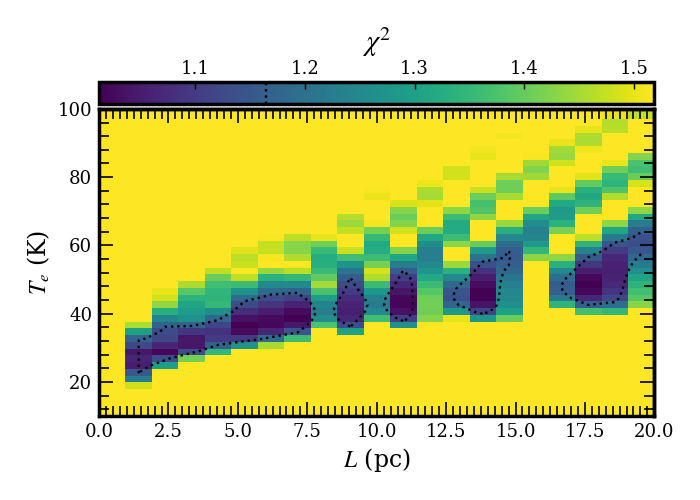

In [12]:
fig_tel, ax_tel = plt.subplots(figsize=(7, 5))
div = make_axes_locatable(ax_tel)
cax = div.append_axes('top', size='7%', pad=0.05)

# Heatmap couleur
im = ax_tel.imshow(
    z_TeL, origin='lower', aspect='auto',
    extent=[x_TeL[0], x_TeL[-1], y_TeL[0], y_TeL[-1]],
    cmap='viridis', vmin=chi2_min, vmax=chi2_lim,
)
# Contour délimitant la région de confiance à +15 %
ax_tel.contour(
    z_TeL, origin='lower',
    extent=[x_TeL[0], x_TeL[-1], y_TeL[0], y_TeL[-1]],
    levels=[1.15 * chi2_min], colors=['k'], linestyles=['dotted'],
)

graphics.set_axes(ax_tel, pad=5)
ax_tel.set_xlabel('$L$ (pc)')
ax_tel.set_ylabel('$T_e$ (K)')
ax_tel.set_ylim(10, 100)

plt.colorbar(im, cax=cax, location='top')
cax.set_title('$\\chi^2$')
cax.axvline(1.15 * chi2_min, color='k', linestyle='dotted')

fig_tel.tight_layout()
fig_tel.savefig('te_l-beam1.pdf')


### 5.2 Plan Te – Ne avec contours colorés par L

La heatmap de fond montre le χ² min marginalisé sur (T0, L, vt).
Chaque contour coloré correspond à une valeur de L fixée et délimite
la région +15 %, ce qui permet de visualiser la dégénérescence Te–Ne–L.


In [13]:
# Heatmap Te–Ne marginalisée
heatmap_TeNe = df.pivot_table(index='Te', columns='Ne', values='chi2', aggfunc='min')
x_TeNe = heatmap_TeNe.columns.values  # valeurs de Ne
y_TeNe = heatmap_TeNe.index.values    # valeurs de Te
z_TeNe = heatmap_TeNe.values


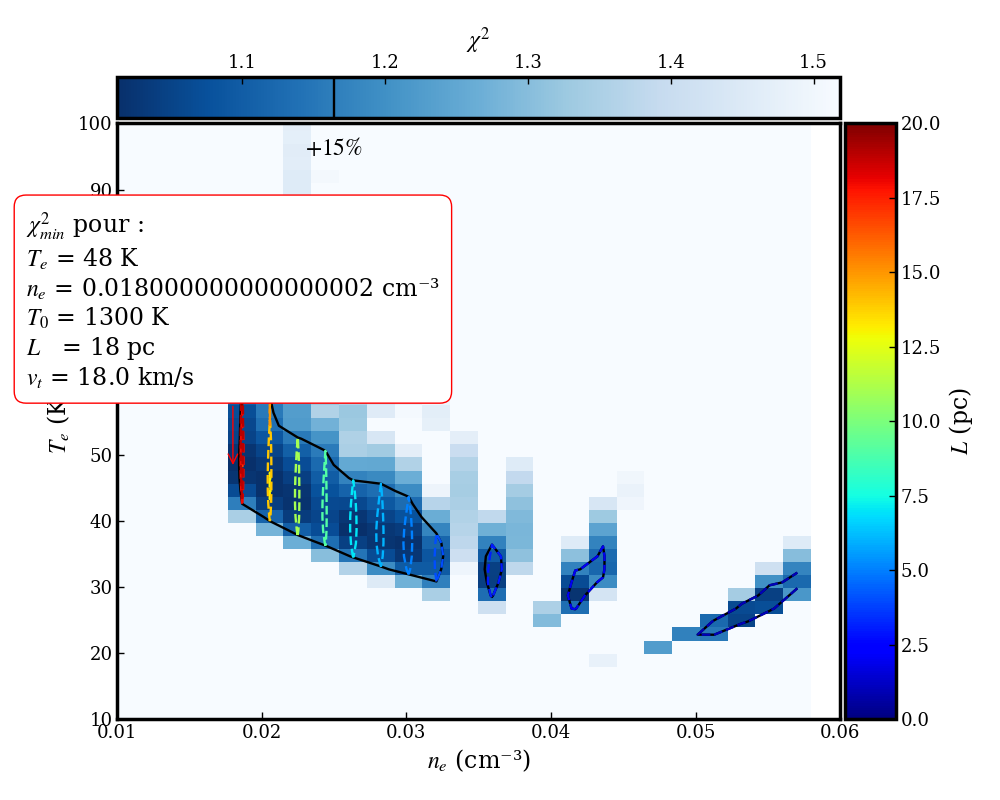

In [14]:
fig_tene, axs = plt.subplots(figsize=(10, 8))
div0    = make_axes_locatable(axs)
cax_top = div0.append_axes('top',   size='7%', pad=0.05)
cax_rgt = div0.append_axes('right', size='7%', pad=0.05)

# ── Heatmap de fond ───────────────────────────────────────────────────────
im_bg = axs.imshow(
    z_TeNe, origin='lower', aspect='auto',
    extent=[x_TeNe[0], x_TeNe[-1], y_TeNe[0], y_TeNe[-1]],
    cmap='Blues_r', vmin=chi2_min, vmax=chi2_lim,
)
# Contour global à +15 %
axs.contour(
    z_TeNe, origin='lower',
    extent=[x_TeNe[0], x_TeNe[-1], y_TeNe[0], y_TeNe[-1]],
    levels=[1.15 * chi2_min], colors=['k'], linestyles=['solid'],
)

# ── Contours colorés par valeur de L ─────────────────────────────────────
# Un contour par valeur de L, couleur codée par jet(i/n_L)
cmap_L = plt.get_cmap('jet', len(L_orig))
for i, l_val in enumerate(L_orig):
    sub = df[df.L == l_val].pivot_table(
        index='Te', columns='Ne', values='chi2', aggfunc='min'
    )
    if sub.empty:
        continue
    axs.contour(
        sub.values, origin='lower',
        extent=[sub.columns[0], sub.columns[-1], sub.index[0], sub.index[-1]],
        levels=[1.15 * chi2_min],
        colors=[cmap_L(i)], linestyles=['dashed'],
    )

# ── Annotation de la solution optimale ───────────────────────────────────
df_opt_tene = df[df.chi2 == z_TeNe.min()]
xm, ym = df_opt_tene.Ne.values[0], df_opt_tene.Te.values[0]
txt  = '$\\chi^2_{min}$ pour :\n'
txt += f'$T_e$ = {df_opt_tene.Te.values[0]} K\n'
txt += f'$n_e$ = {df_opt_tene.Ne.values[0]} cm\u207b\u00b3\n'
txt += f'$T_0$ = {df_opt_tene.T0.values[0]} K\n'
txt += f'$L$   = {df_opt_tene.L.values[0]} pc\n'
txt += f'$v_t$ = {df_opt_tene.vt.values[0]} km/s'
axs.annotate(
    txt, (xm, ym), xytext=(0, 120), textcoords='offset points',
    color='k', arrowprops={'color': 'r', 'arrowstyle': '->'},
    bbox=dict(boxstyle='round,pad=0.5', ec='r', fc='w'),
    ha='center', va='center', multialignment='left',
)

axs.set_ylim(10, 100)
axs.set_xlim(1e-2, 6e-2)
axs.set_xlabel('$n_e$ (cm\u207b\u00b3)')
axs.set_ylabel('$T_e$ (K)')

# ── Colorbars ─────────────────────────────────────────────────────────────
norm_L = mpl.colors.Normalize(vmin=L_orig.min(), vmax=L_orig.max())
fig_tene.colorbar(mpl.cm.ScalarMappable(norm=norm_L, cmap='jet'),
                  cax=cax_rgt, location='right', label='$L$ (pc)')
fig_tene.colorbar(im_bg, cax=cax_top, location='top', label='$\\chi^2$')
cax_top.axvline(1.15 * chi2_min, color='k')
cax_top.text(1.15 * chi2_min, -1, '$+15\\%$', va='bottom', ha='center')

fig_tene.tight_layout()
fig_tene.savefig('space-param-beam1.pdf')


## 6. Sélection fine par masque géométrique dans le plan (Te, L)

On exclut certaines zones de l'espace (Te, L) pour ne garder que les
solutions physiquement plausibles. La condition `cond` définit les points
**à exclure** (mise à NaN). Adapter selon la source / le faisceau.


In [15]:
# Grille 2D Te×L pour les conditions de masquage
LL, TE = np.meshgrid(x_TeL, y_TeL)  # shape (nTe, nL)

# ── Condition d'exclusion ─────────────────────────────────────────────────
# Modifier selon la source :
#   beam2 : cond = (LL < 21.5) | (TE < funclo(LL))
#   beam3 : cond = (LL < 9) | (LL > 12)
cond = LL > 32   # exclure les lignes de visée trop longues


def make_masked_heatmap(df_subset, x_cols, y_idx, cond):
    """
    Pivote df_subset en heatmap (Te, L), reindexe sur la grille complète
    et applique le masque `cond` (valeurs exclues → NaN).
    """
    hm = df_subset.pivot_table(
        index='Te', columns='L', values='chi2', aggfunc='min'
    ).reindex(columns=x_cols, index=y_idx)
    vals = hm.values.copy()
    vals[cond] = np.nan
    return vals


z_masked15 = make_masked_heatmap(df_best15, x_TeL, y_TeL, cond)
z_masked30 = make_masked_heatmap(df_best30, x_TeL, y_TeL, cond)

# Sous-ensemble de solutions retenues (chi2 présents dans la zone non masquée)
valid_chi2  = np.unique(z_masked15[~np.isnan(z_masked15)])
df_solution = df_best15[df_best15['chi2'].isin(valid_chi2)]
print(f'{len(df_solution)} points retenus après masquage.')
df_solution


84 points retenus après masquage.


,Te,Ne,T0,L,vt,chi2
8988086,22,0.052,1000,1,18.0,1.154022
10353085,24,0.054,1000,1,17.5,1.052337
11351686,26,0.042,1100,2,18.0,1.134818
11665585,26,0.054,1000,1,17.5,1.065046
12506736,28,0.036,1100,3,18.0,1.131529
...,...,...,...,...,...,...
31724686,58,0.018,1300,20,18.0,1.150391
31775886,58,0.020,1200,15,18.0,1.162616
33037135,60,0.018,1300,19,17.5,1.146794
33037185,60,0.018,1300,20,17.5,1.134650


In [17]:
# ── Résumé des plages de paramètres ──────────────────────────────────────
chi2_opt = df_solution['chi2'].min()
df_opt   = df_solution[df_solution['chi2'] == chi2_opt]

header = f"{'Param':<6}{'min':>12}{'max':>12}{'optimal':>12}"
print(header)
print('-' * len(header))
for col in ['Te', 'Ne', 'T0', 'L', 'vt']:
    print(f"{col:<6}{df_solution[col].min():>12.4g}"
          f"{df_solution[col].max():>12.4g}"
          f"{df_opt[col].values[0]:>12.4g}")


Param          min         max     optimal
------------------------------------------
Te              22          62          48
Ne           0.018       0.058       0.018
T0             900        1300        1300
L                1          20          18
vt            17.5          18          18


## 7. Histogrammes marginaux des paramètres retenus

Distribution de chaque paramètre dans la région de confiance sélectionnée.
La ligne rouge indique la valeur optimale.


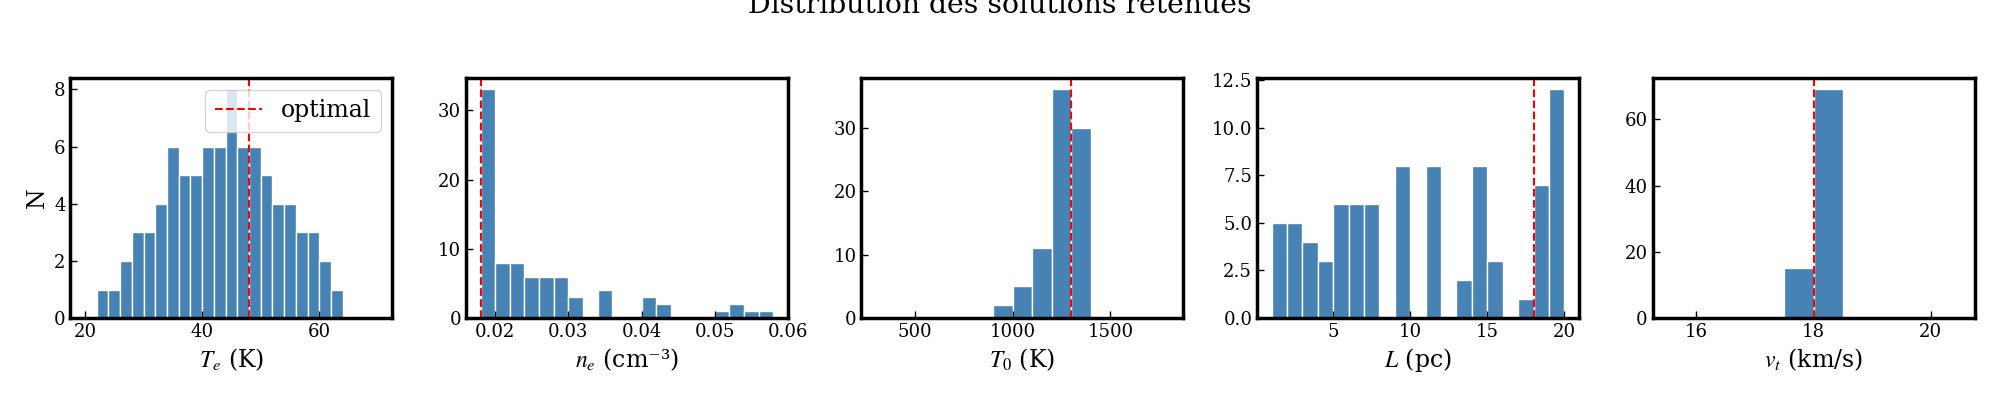

In [18]:
PARAMS = ['Te', 'Ne', 'T0', 'L', 'vt']
PARAM_AXES = {'Te': Te_orig, 'Ne': Ne_orig, 'T0': T0_orig,
              'L': L_orig,   'vt': vt_orig}
PARAM_LABELS = {
    'Te': '$T_e$ (K)',      'Ne': '$n_e$ (cm\u207b\u00b3)',
    'T0': '$T_0$ (K)',      'L':  '$L$ (pc)',
    'vt': '$v_t$ (km/s)',
}

fig_hist, axhists = plt.subplots(1, 5, figsize=(20, 4))
for ax_h, p in zip(axhists, PARAMS):
    ax_orig = PARAM_AXES[p]
    d_step  = ax_orig[1] - ax_orig[0]              # pas de la grille
    exten   = np.unique(df_best30[p])
    bins    = np.arange(exten[0], exten[-1] + d_step, d_step)

    ax_h.hist(df_solution[p], bins=bins, color='steelblue', edgecolor='white')
    ax_h.axvline(df_opt[p].values[0], color='r', lw=1.5, ls='--', label='optimal')
    ax_h.set_xlabel(PARAM_LABELS[p])
    if p == 'Te':
        ax_h.set_ylabel('N')
        ax_h.legend()

fig_hist.suptitle('Distribution des solutions retenues', y=1.02)
fig_hist.tight_layout()


## 8. Modèle optimal vs données observées

Comparaison de la largeur de raie de Voigt modélisée avec les mesures en
fonction du nombre quantique `n`. L'enveloppe colorée couvre la plage de
Te dans la solution retenue (incertitude sur Te à Ne, T0, L, vt fixés).


In [19]:
# ── Paramètres optimaux ──────────────────────────────────────────────────
Te_opt = df_opt.Te.values[0]
Ne_opt = df_opt.Ne.values[0]
T0_opt = df_opt.T0.values[0]
L_opt  = df_opt.L.values[0]
vt_opt = df_opt.vt.values[0]

# Enveloppe d'incertitude sur Te
Te_min = df_solution['Te'].min()
Te_max = df_solution['Te'].max()

print(f'Optimal : Te={Te_opt} K | Ne={Ne_opt:.4f} cm⁻³ | '
      f'T0={T0_opt} K | L={L_opt} pc | vt={vt_opt} km/s')
print(f'Enveloppe Te : [{Te_min}, {Te_max}] K')


Optimal : Te=48 K | Ne=0.0180 cm⁻³ | T0=1300 K | L=18 pc | vt=18.0 km/s
Enveloppe Te : [22, 62] K


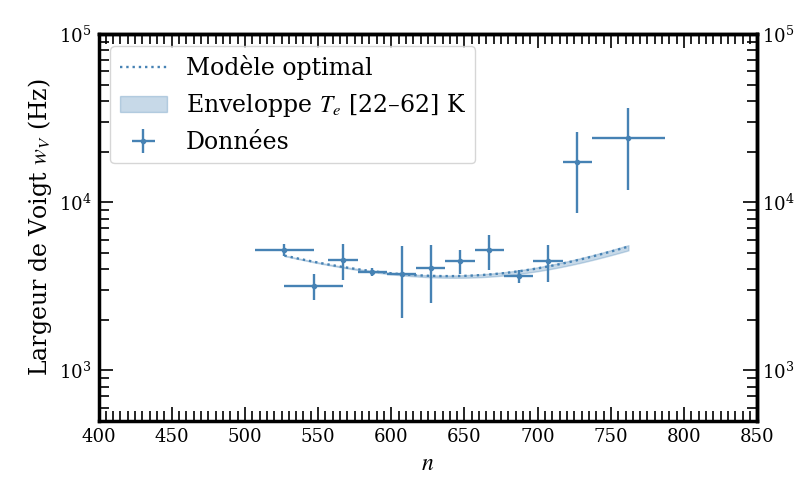

In [20]:
# ── Données observées ────────────────────────────────────────────────────
obs_df = pd.read_csv(CSV_PATH + csv_file)
QUAN   = obs_df['n'].values
WV     = obs_df['wV'].values    # largeur de Voigt mesurée [Hz]
DWV    = obs_df['dwV'].values   # incertitude sur wV

# Incertitude en n (résolution de grille, typiquement ±10 canaux)
XERR = np.full(len(QUAN), 10.0)
XERR[0]  = 20.0   # incertitude plus large pour les premières raies
XERR[1]  = 20.0
XERR[-1] = 25.0   # et la dernière

# Grille continue pour le modèle
quantum = np.arange(QUAN.min(), QUAN.max() + 1)

# ── Évaluation des modèles ────────────────────────────────────────────────
# total_broadening retourne la FWHM de Voigt en MHz → conversion en Hz
model_opt = mdl.total_broadening(quantum, Ne_opt, Te_opt, T0_opt, vt_opt) * 1e6
model_min = mdl.total_broadening(quantum, Ne_opt, Te_min, T0_opt, vt_opt) * 1e6
model_max = mdl.total_broadening(quantum, Ne_opt, Te_max, T0_opt, vt_opt) * 1e6

# ── Figure ────────────────────────────────────────────────────────────────
fig_model, ax_w = plt.subplots(figsize=(8, 5))
graphics.set_axes(ax_w, pad=5)
ax_w.set_yscale('log')

ax_w.errorbar(QUAN, WV, xerr=XERR, yerr=DWV,
              fmt='.', color='steelblue', label='Données')
ax_w.plot(quantum, model_opt, ls='dotted', color='steelblue', label='Modèle optimal')
ax_w.fill_between(
    quantum, model_min, model_max,
    color='steelblue', alpha=0.3,
    label=f'Enveloppe $T_e$ [{Te_min}–{Te_max}] K',
)

ax_w.set_xlabel('$n$')
ax_w.set_ylabel('Largeur de Voigt $w_V$ (Hz)')
ax_w.set_xlim(400, 850)
ax_w.set_ylim(5e2, 1e5)
ax_w.legend()
fig_model.tight_layout()


## Annexe – Fonctions utilitaires


In [21]:
# weighted_avg_and_std moved to spectral_tools.tools
from spectral_tools.tools import weighted_avg_and_std
